In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
import joblib
import os

os.makedirs('models', exist_ok=True)
print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv(r'D:\Not Backed up\Study Materials\BCA\8th Semester\Project\agrismart-ai\data\Crop_recommendation.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nCrop types:", df['label'].unique())
print("\nAny missing values?", df.isnull().sum().any())

Shape: (2200, 8)

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Column names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Crop types: <StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

Any missing values? False


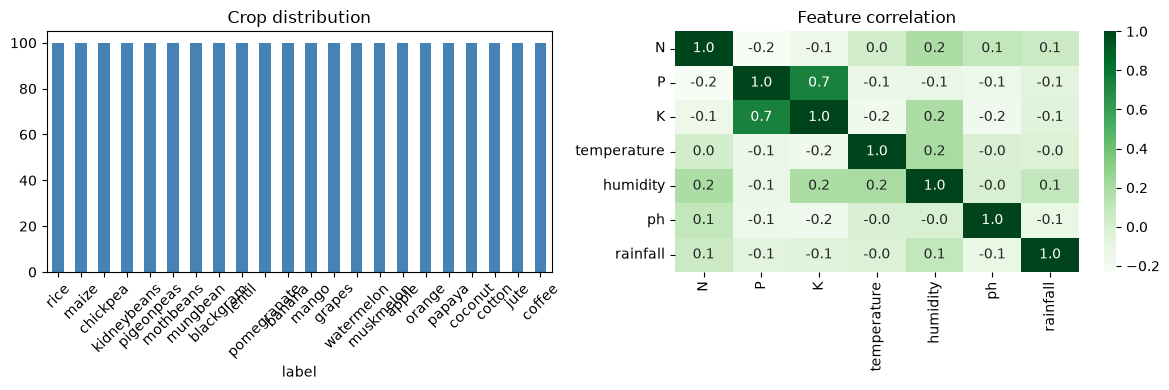

Charts saved


In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Crop distribution')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(1, 2, 2)
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, fmt='.1f', cmap='Greens')
plt.title('Feature correlation')
plt.tight_layout()

plt.savefig('models/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved")

In [4]:
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Number of crops:", len(le.classes_))

joblib.dump(le, 'models/label_encoder.pkl')
print("Label encoder saved")

Training samples: 1760
Test samples: 440
Number of crops: 22
Label encoder saved


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

joblib.dump(rf_model, 'models/random_forest_model.pkl')
print("Random Forest model saved")

Random Forest Accuracy: 99.32%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00   

In [6]:
# Simulate yield from soil features (for demo purposes)
df['yield_kg'] = (
    df['N'] * 2.1 +
    df['P'] * 1.8 +
    df['K'] * 1.5 +
    df['rainfall'] * 0.9 +
    np.random.normal(0, 50, len(df))
).round(1)

X_yield = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y_yield = df['yield_kg']

X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yield, y_yield, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_y, y_train_y)

y_pred_y = lr_model.predict(X_test_y)
r2 = r2_score(y_test_y, y_pred_y)
rmse = np.sqrt(mean_squared_error(y_test_y, y_pred_y))

print(f"Linear Regression R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f} kg/hectare")

joblib.dump(lr_model, 'models/linear_regression_model.pkl')
print("Linear Regression model saved")

Linear Regression R² Score: 0.8757
RMSE: 51.42 kg/hectare
Linear Regression model saved


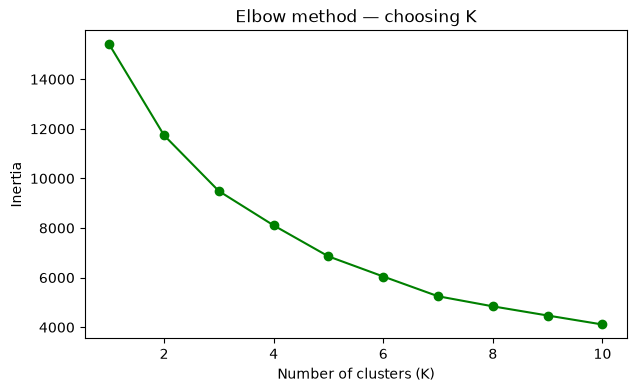

Cluster sizes:
  Zone 1 — Humid Fertile: 797 samples
  Zone 2 — Dry Arid: 618 samples
  Zone 3 — Moderate Temperate: 585 samples
  Zone 4 — High Rainfall: 200 samples
K-Means and scaler saved


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to confirm k=4
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker='o', color='green')
plt.title('Elbow method — choosing K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.savefig('models/elbow_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Train final model with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

zone_labels = {0: "Zone 1 — Humid Fertile", 1: "Zone 2 — Dry Arid",
               2: "Zone 3 — Moderate Temperate", 3: "Zone 4 — High Rainfall"}
print("Cluster sizes:")
for i, count in enumerate(pd.Series(kmeans.labels_).value_counts().sort_index()):
    print(f"  {zone_labels[i]}: {count} samples")

joblib.dump(kmeans, 'models/kmeans_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("K-Means and scaler saved")

In [8]:
# Sample input — feel free to change these values
sample = {
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 20.8, 'humidity': 82.0,
    'ph': 6.5, 'rainfall': 202.9
}

sample_df = pd.DataFrame([sample])

# 1. Crop recommendation
crop_encoded = rf_model.predict(sample_df)[0]
crop_name = le.inverse_transform([crop_encoded])[0]
crop_prob = rf_model.predict_proba(sample_df)[0].max()
print(f"Recommended crop: {crop_name.upper()} ({crop_prob*100:.1f}% confidence)")

# 2. Yield prediction
predicted_yield = lr_model.predict(sample_df)[0]
print(f"Expected yield: {predicted_yield:.0f} kg/hectare")

# 3. Farming zone
sample_scaled = scaler.transform(sample_df)
zone = kmeans.predict(sample_scaled)[0]
print(f"Farming zone: {zone_labels[zone]}")

Recommended crop: RICE (99.0% confidence)
Expected yield: 515 kg/hectare
Farming zone: Zone 2 — Dry Arid


In [9]:
import subprocess
subprocess.run(['git', 'add', '.'], cwd=r'D:\Not Backed up\Study Materials\BCA\8th Semester\Project\agrismart-ai')
subprocess.run(['git', 'commit', '-m', 'Day 2: trained all 3 models - RF, LR, KMeans'], cwd=r'D:\Not Backed up\Study Materials\BCA\8th Semester\Project\agrismart-ai')
subprocess.run(['git', 'push', 'origin', 'main'], cwd=r'D:\Not Backed up\Study Materials\BCA\8th Semester\Project\agrismart-ai')
print("Pushed to GitHub")

Pushed to GitHub


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [18]:
#Train and compare all classifiers:

from sklearn.preprocessing import StandardScaler as SC

# Scale data for models that need it
sc = SC()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

models = {
    "Random Forest":          (rf_model,                                    X_train,        X_test),
    "Logistic Regression":    (LogisticRegression(max_iter=5000, solver='saga', random_state=42), X_train_scaled, X_test_scaled),
    "Support Vector Machine": (SVC(random_state=42),                        X_train_scaled, X_test_scaled),
    "K-Nearest Neighbours":   (KNeighborsClassifier(),                      X_train_scaled, X_test_scaled),
    "Decision Tree":          (DecisionTreeClassifier(random_state=42),     X_train,        X_test),
}

print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("=" * 45)

results = {}
for name, (model, X_tr, X_te) in models.items():
    if name != "Random Forest":
        model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds) * 100
    results[name] = acc
    print(f"{name:<25} {acc:>9.2f}%")

print("=" * 45)

Model                       Accuracy
Random Forest                 99.32%
Logistic Regression           96.36%
Support Vector Machine        96.82%
K-Nearest Neighbours          95.68%
Decision Tree                 98.64%


In [14]:
#Linear Regression metrics:

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_lr = lr_model.predict(X_test_y)
r2   = r2_score(y_test_y, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_y, y_pred_lr))

print(f"Linear Regression R² Score : {r2:.4f}")
print(f"Linear Regression RMSE     : {rmse:.2f} kg/hectare")

Linear Regression R² Score : 0.8757
Linear Regression RMSE     : 51.42 kg/hectare


In [15]:
#K-Means silhouette score:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_scaled, kmeans.labels_)
print(f"K-Means Silhouette Score: {sil:.4f}")

K-Means Silhouette Score: 0.2553


In [19]:
#Print everything together
print("=" * 50)
print("ABSTRACT PLACEHOLDER VALUES")
print("=" * 50)

# Classifier comparison
results = {}
for name, (model, X_tr, X_te) in models.items():
    if name != "Random Forest":
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds) * 100

for name, acc in results.items():
    print(f"{name:<30}: {acc:.2f}%")

print()
print(f"Linear Regression R²       : {r2:.4f}")
print(f"Linear Regression RMSE     : {rmse:.2f} kg/hectare")
print(f"K-Means Silhouette Score   : {sil:.4f}")
print()
print("Dataset : Crop Recommendation Dataset (Kaggle)")
print("Records : 2,200")
print("Features: N, P, K, Temperature, Humidity, pH, Rainfall")
print("Classes : 22 crop types")
print("=" * 50)

ABSTRACT PLACEHOLDER VALUES
Random Forest                 : 99.32%
Logistic Regression           : 94.32%
Support Vector Machine        : 96.14%
K-Nearest Neighbours          : 97.05%
Decision Tree                 : 98.64%

Linear Regression R²       : 0.8757
Linear Regression RMSE     : 51.42 kg/hectare
K-Means Silhouette Score   : 0.2553

Dataset : Crop Recommendation Dataset (Kaggle)
Records : 2,200
Features: N, P, K, Temperature, Humidity, pH, Rainfall
Classes : 22 crop types
